## Problem 2

<div style="text-align:center;">
    <img src="Problem2.png" width=600">
</div>

### Part 1

In [66]:
def cross_matrix(vec):
    
    return np.array([[0, -vec[2], vec[1]],
                      [vec[2], 0, -vec[0]],
                      [-vec[1], vec[0], 0]])

### Part 2

In [67]:
def uncross_matrix(mat):
    
    return np.array([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

### Part 3

In [68]:
def omega_dot(t, omega, I_B):
    skew_omega = cross_matrix(omega)
    return -np.linalg.inv(I_B) @ (skew_omega @ I_B @ omega)

### Part 4

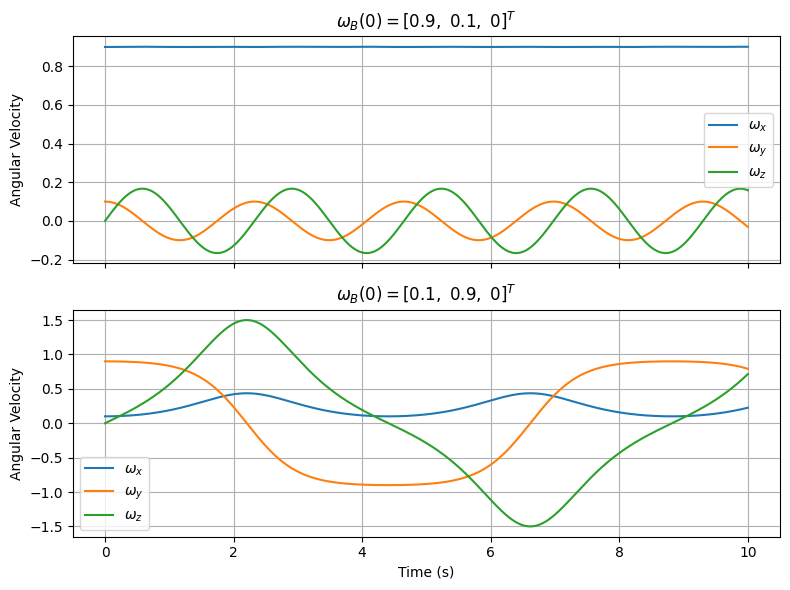

In [69]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

omega0 = np.array([0.1,0.9,0])
I_B = np.array([[10, 0, 0],
                [0,  5, 0],
                [0,  0, 1]], dtype=float)

# Simulation time 10 seconds
time = np.linspace(0,10,1000)

# Initial Conditions
omega0_a = np.array([0.9,0.1,0.0])
omega0_b = np.array([0.1,0.9,0.0])

sol_a = solve_ivp(lambda t,y: omega_dot(t,y,I_B),
                  [0,10], omega0_a,
                  t_eval=time, atol=1e-8, rtol=1e-8)

sol_b = solve_ivp(lambda t,y: omega_dot(t,y,I_B),
                  [0,10], omega0_b,
                  t_eval=time, atol=1e-8, rtol=1e-8)

# Create subplots
fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

# ---- First initial condition ----
ax[0].plot(sol_a.t, sol_a.y[0], label=r'$\omega_x$')
ax[0].plot(sol_a.t, sol_a.y[1], label=r'$\omega_y$')
ax[0].plot(sol_a.t, sol_a.y[2], label=r'$\omega_z$')

ax[0].set_title(r'$\omega_B(0)=[0.9,\ 0.1,\ 0]^T$')
ax[0].set_ylabel('Angular Velocity')
ax[0].grid(True)
ax[0].legend()

# ---- Second initial condition ----
ax[1].plot(sol_b.t, sol_b.y[0], label=r'$\omega_x$')
ax[1].plot(sol_b.t, sol_b.y[1], label=r'$\omega_y$')
ax[1].plot(sol_b.t, sol_b.y[2], label=r'$\omega_z$')

ax[1].set_title(r'$\omega_B(0)=[0.1,\ 0.9,\ 0]^T$')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Angular Velocity')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

### Part 5

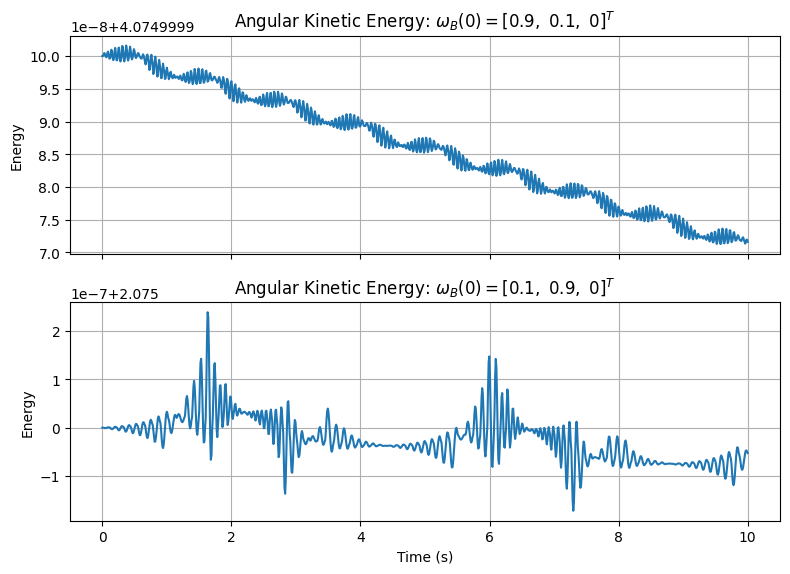

In [70]:
# Angular kinetic energy function
def kinetic_energy(omega, I_B):
    return 0.5 * omega.T @ I_B @ omega

# 
energy_a = np.array([kinetic_energy(sol_a.y[:, i], I_B) for i in range(len(sol_a.t))])
energy_b = np.array([kinetic_energy(sol_b.y[:, i], I_B) for i in range(len(sol_b.t))])

# plot both cases as subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax[0].plot(sol_a.t, energy_a)
ax[0].set_title(r'Angular Kinetic Energy: $\omega_B(0)=[0.9,\ 0.1,\ 0]^T$')
ax[0].set_ylabel('Energy')
ax[0].grid(True)

ax[1].plot(sol_b.t, energy_b)
ax[1].set_title(r'Angular Kinetic Energy: $\omega_B(0)=[0.1,\ 0.9,\ 0]^T$')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Energy')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Problem 3

<div style="text-align:center;">
    <img src="Problem3.png" width="600">
</div>

### Part 1

The system of the simple hopper has a 2D rigid-body which has 2-links,the second link has its own angle and a variable length. Therefore, we need 5 variables in order to fully defined the motion of the system

In [71]:
import sympy as sp

# Configuration variables
x, y = sp.symbols('x y', real=True)          
theta, phi = sp.symbols('theta phi', real=True)  
l = sp.symbols('l', real=True)           

# Full configuration vector q
q = sp.Matrix([x, y, theta, phi, l])

# Pose variables
pose = sp.Matrix([x, y, theta])

# Shape variables
shape = sp.Matrix([phi, l])

In [72]:
print('Configuration variables q:')
q

Configuration variables q:


⎡x⎤
⎢ ⎥
⎢y⎥
⎢ ⎥
⎢θ⎥
⎢ ⎥
⎢φ⎥
⎢ ⎥
⎣l⎦

In [73]:
print('Pose variables:')
pose

Pose variables:


⎡x⎤
⎢ ⎥
⎢y⎥
⎢ ⎥
⎣θ⎦

In [74]:
print('Shape variables:')
shape

Shape variables:


⎡φ⎤
⎢ ⎥
⎣l⎦

### Part 2

Since the hopper has 5 configuration variables (x,y,θ,ϕ,l), the mass matrix has dimension 5×5.

### Part 3

In [1]:
import sympy as sp
from sympy import Matrix, cos, sin, simplify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Time
t = sp.symbols('t', real=True)

# Constants
m1, m2, w, g, omega = sp.symbols('m1 m2 w g omega', real=True)

# Configuration variables as a function of time
x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
phi = sp.Function('phi')(t)
l = sp.Function('l')(t)

q = sp.Matrix([x, y, theta, phi, l])
qd = q.diff(t)
qdd = q.diff(t, 2)

# Helper Functions provided by the professor
def cross_matrix(vec):
    
    return np.array([[0, -vec[2,0], vec[1,0]],
                   [vec[2,0], 0, -vec[0,0]],
                   [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.array([[mat[2,1]],
                   [mat[0,2]], 
                   [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return m
    
def R_z(theta):
    return np.array([[cos(theta), -sin(theta), 0], 
                   [sin(theta),  cos(theta), 0],
                   [0,           0,          1]])

def R_y(theta):
    return np.array([[cos(theta), 0, sin(theta)], 
                   [0,          1, 0],
                   [-sin(theta),0, cos(theta)]])

def R_x(theta):
    return np.array([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta),  cos(theta)]])

def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

# World to body center
T01 = T(R_z(theta), Matrix([[x], [y], [0]]))
T01 = simplify(T01)

# Right and left masses
T1_right = T01 @ T(sp.eye(3), Matrix([[ w], [0], [0]]))
T1_right = simplify(T1_right)

T1_left  = T01 @ T(sp.eye(3), Matrix([[-w], [0], [0]]))
T1_left = simplify(T1_left)

# Leg mass
T2 = T01 @ T(R_z(phi), Matrix([[0], [0], [0]])) @ T(sp.eye(3), Matrix([[0], [-l], [0]]))
T2 = simplify(T2)

# Positions (for potential energy)
p_right = simplify(T1_right[:3, 3])
p_left  = simplify(T1_left[:3, 3])
p_leg   = simplify(T2[:3, 3])

# Twist matrices: V^ = T^{-1} Tdot
Vhat_right = simplify(T1_right.inv() @ T1_right.diff(t))
Vhat_left  = simplify(T1_left.inv()  @ T1_left.diff(t))
Vhat_leg   = simplify(T2.inv()       @ T2.diff(t))

# Twist vectors
Vb_right = simplify(twist2vec(Vhat_right))
Vb_left  = simplify(twist2vec(Vhat_left))
Vb_leg   = simplify(twist2vec(Vhat_leg))

# Generalized inertia matrices for point masses
G_right = Matrix.zeros(6,6)
G_right[3:,3:] = m1 * sp.eye(3)

G_left = Matrix.zeros(6,6)
G_left[3:,3:] = m1 * sp.eye(3)

G_leg = Matrix.zeros(6,6)
G_leg[3:,3:] = m2 * sp.eye(3)

# Kinetic energies
K_right = simplify(sp.Rational(1,2) * (Vb_right.T @ G_right @ Vb_right)[0])
K_left  = simplify(sp.Rational(1,2) * (Vb_left.T  @ G_left  @ Vb_left )[0])
K_leg   = simplify(sp.Rational(1,2) * (Vb_leg.T   @ G_leg   @ Vb_leg  )[0])

K = simplify(K_right + K_left + K_leg)

# Potential energies
P = simplify(
    m1 * g * p_right[1] +
    m1 * g * p_left[1] +
    m2 * g * p_leg[1]
)

In [58]:
print("Kinetic Energy K:")
K

Kinetic Energy K:


m1*w**2*Derivative(theta(t), t)**2 + m1*Derivative(x(t), t)**2 + m1*Derivative(y(t), t)**2 + m2*l(t)**2*Derivative(phi(t), t)**2/2 + m2*l(t)**2*Derivative(phi(t), t)*Derivative(theta(t), t) + m2*l(t)**2*Derivative(theta(t), t)**2/2 + m2*l(t)*sin(phi(t) + theta(t))*Derivative(phi(t), t)*Derivative(y(t), t) + m2*l(t)*sin(phi(t) + theta(t))*Derivative(theta(t), t)*Derivative(y(t), t) + m2*l(t)*cos(phi(t) + theta(t))*Derivative(phi(t), t)*Derivative(x(t), t) + m2*l(t)*cos(phi(t) + theta(t))*Derivative(theta(t), t)*Derivative(x(t), t) + m2*sin(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(x(t), t) - m2*cos(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(y(t), t) + m2*Derivative(l(t), t)**2/2 + m2*Derivative(x(t), t)**2/2 + m2*Derivative(y(t), t)**2/2

### Part 4

In [59]:
print("Potential Energy P:")
P

Potential Energy P:


g*(2*m1*y(t) - m2*l(t)*cos(phi(t) + theta(t)) + m2*y(t))

### Part 5

In [60]:
L = simplify(K - P)

tau_phi = sin(omega * t)
tau_l = cos(omega * t)

Q = Matrix([0, 0, 0, tau_phi, tau_l])

EL = Matrix([
    simplify(sp.diff(sp.diff(L, qd[i]), t) - sp.diff(L, q[i]) - Q[i])
    for i in range(len(q))
])

M = simplify(EL.jacobian(qdd))
c = simplify(EL - M*qdd)

In [61]:
print("Euler-Lagrange equations:")
EL

Euler-Lagrange equations:


Matrix([
[                2*m1*Derivative(x(t), (t, 2)) - m2*l(t)*sin(phi(t) + theta(t))*Derivative(phi(t), t)**2 - 2*m2*l(t)*sin(phi(t) + theta(t))*Derivative(phi(t), t)*Derivative(theta(t), t) - m2*l(t)*sin(phi(t) + theta(t))*Derivative(theta(t), t)**2 + m2*l(t)*cos(phi(t) + theta(t))*Derivative(phi(t), (t, 2)) + m2*l(t)*cos(phi(t) + theta(t))*Derivative(theta(t), (t, 2)) + m2*sin(phi(t) + theta(t))*Derivative(l(t), (t, 2)) + 2*m2*cos(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(phi(t), t) + 2*m2*cos(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(theta(t), t) + m2*Derivative(x(t), (t, 2))],
[2*g*m1 + g*m2 + 2*m1*Derivative(y(t), (t, 2)) + m2*l(t)*sin(phi(t) + theta(t))*Derivative(phi(t), (t, 2)) + m2*l(t)*sin(phi(t) + theta(t))*Derivative(theta(t), (t, 2)) + m2*l(t)*cos(phi(t) + theta(t))*Derivative(phi(t), t)**2 + 2*m2*l(t)*cos(phi(t) + theta(t))*Derivative(phi(t), t)*Derivative(theta(t), t) + m2*l(t)*cos(phi(t) + theta(t))*Derivative(theta(t), t)**2 + 2*m2*sin(phi(t) + thet

In [62]:
print("Mass-matrix:")
M

Mass-matrix:


Matrix([
[                     2*m1 + m2,                              0, m2*l(t)*cos(phi(t) + theta(t)), m2*l(t)*cos(phi(t) + theta(t)),  m2*sin(phi(t) + theta(t))],
[                             0,                      2*m1 + m2, m2*l(t)*sin(phi(t) + theta(t)), m2*l(t)*sin(phi(t) + theta(t)), -m2*cos(phi(t) + theta(t))],
[m2*l(t)*cos(phi(t) + theta(t)), m2*l(t)*sin(phi(t) + theta(t)),         2*m1*w**2 + m2*l(t)**2,                     m2*l(t)**2,                          0],
[m2*l(t)*cos(phi(t) + theta(t)), m2*l(t)*sin(phi(t) + theta(t)),                     m2*l(t)**2,                     m2*l(t)**2,                          0],
[     m2*sin(phi(t) + theta(t)),     -m2*cos(phi(t) + theta(t)),                              0,                              0,                         m2]])

In [63]:
print("\nRemaining terms c(q, qdot) =")
c


Remaining terms c(q, qdot) =


Matrix([
[                         m2*(-l(t)*sin(phi(t) + theta(t))*Derivative(phi(t), t)**2 - 2*l(t)*sin(phi(t) + theta(t))*Derivative(phi(t), t)*Derivative(theta(t), t) - l(t)*sin(phi(t) + theta(t))*Derivative(theta(t), t)**2 + 2*cos(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(phi(t), t) + 2*cos(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(theta(t), t))],
[2*g*m1 + g*m2 + m2*l(t)*cos(phi(t) + theta(t))*Derivative(phi(t), t)**2 + 2*m2*l(t)*cos(phi(t) + theta(t))*Derivative(phi(t), t)*Derivative(theta(t), t) + m2*l(t)*cos(phi(t) + theta(t))*Derivative(theta(t), t)**2 + 2*m2*sin(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(phi(t), t) + 2*m2*sin(phi(t) + theta(t))*Derivative(l(t), t)*Derivative(theta(t), t)],
[                                                                                                                                                                                                                                      m2*(g*sin(phi(t) + theta(t)) + 2*Der

### Part 6

In [64]:
# Element at row 2, column 3
M_23 = sp.simplify(M[1,2])
M_23

m2*l(t)*sin(phi(t) + theta(t))

### Part 7

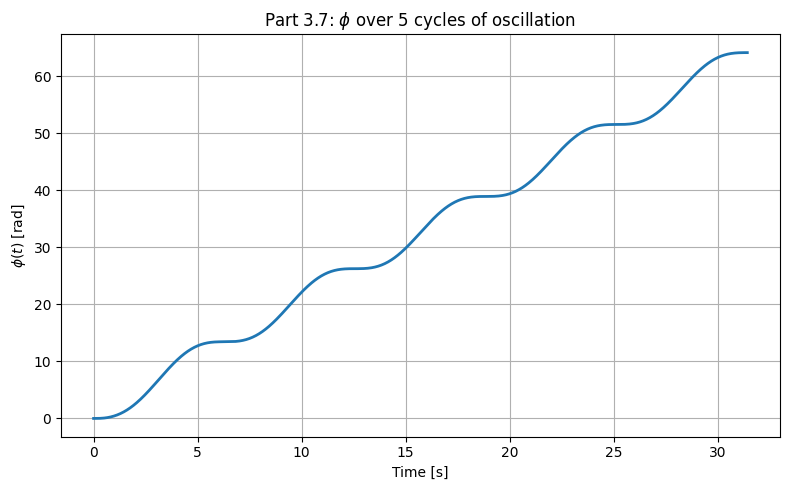

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Replacing symbolic variables with algebraic equations
x_s, y_s, theta_s, phi_s, l_s = sp.symbols('x_s y_s theta_s phi_s l_s', real=True)
xd_s, yd_s, thetad_s, phid_s, ld_s = sp.symbols('xd_s yd_s thetad_s phid_s ld_s', real=True)

subs_dict = {
    x: x_s,
    y: y_s,
    theta: theta_s,
    phi: phi_s,
    l: l_s,
    sp.diff(x, t): xd_s,
    sp.diff(y, t): yd_s,
    sp.diff(theta, t): thetad_s,
    sp.diff(phi, t): phid_s,
    sp.diff(l, t): ld_s
}

# Substitute into symbolic matrices
M_num = sp.simplify(M.subs(subs_dict))
f_num = sp.simplify(f.subs(subs_dict))

# Lambdify
M_func = sp.lambdify(
    (t, x_s, y_s, theta_s, phi_s, l_s,
     xd_s, yd_s, thetad_s, phid_s, ld_s,
     m1, m2, w, g, omega),
    M_num,
    'numpy'
)

f_func = sp.lambdify(
    (t, x_s, y_s, theta_s, phi_s, l_s,
     xd_s, yd_s, thetad_s, phid_s, ld_s,
     m1, m2, w, g, omega),
    f_num,
    'numpy'
)

# ODE function
def hopper_dynamics(t_num, z, params):

    m1_val, m2_val, w_val, g_val, omega_val = params

    x_val, y_val, theta_val, phi_val, l_val, xd_val, yd_val, thetad_val, phid_val, ld_val = z

    # Evaluate mass matrix
    M_eval = np.array(M_func(
        t_num,
        x_val, y_val, theta_val, phi_val, l_val,
        xd_val, yd_val, thetad_val, phid_val, ld_val,
        m1_val, m2_val, w_val, g_val, omega_val
    ), dtype=float)

    # Evaluate forcing vector
    f_eval = np.array(f_func(
        t_num,
        x_val, y_val, theta_val, phi_val, l_val,
        xd_val, yd_val, thetad_val, phid_val, ld_val,
        m1_val, m2_val, w_val, g_val, omega_val
    ), dtype=float).reshape(-1)

    # Solve M qdd + f = 0
    qdd = np.linalg.solve(M_eval, -f_eval)

    dzdt = np.array([
        xd_val,
        yd_val,
        thetad_val,
        phid_val,
        ld_val,
        qdd[0],
        qdd[1],
        qdd[2],
        qdd[3],
        qdd[4]
    ], dtype=float)

    return dzdt

# Constants
m1_val = 1.0
m2_val = 1.0
w_val = 0.5
g_val = 9.81
omega_val = 1.0

params = (m1_val, m2_val, w_val, g_val, omega_val)

# Initial conditions
z0 = np.array([
    0.0,   # x
    1.0,   # y
    0.0,   # theta
    0.0,   # phi
    1.0,   # l
    0.0,   # xdot
    0.0,   # ydot
    0.0,   # thetadot
    0.0,   # phidot
    0.0    # ldot
], dtype=float)

# Simulate over 5 cycles
T_cycle = 2*np.pi / omega_val
t_final = 5 * T_cycle

t_eval = np.linspace(0, t_final, 1000)

sol = solve_ivp(
    fun=lambda t_num, z: hopper_dynamics(t_num, z, params),
    t_span=(0, t_final),
    y0=z0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10
)

# Plot
phi_sol = sol.y[3, :]

plt.figure(figsize=(8,5))
plt.plot(sol.t, phi_sol, linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel(r'$\phi(t)$ [rad]')
plt.title(r'Part 3.7: $\phi$ over 5 cycles of oscillation')
plt.grid(True)
plt.tight_layout()
plt.show()

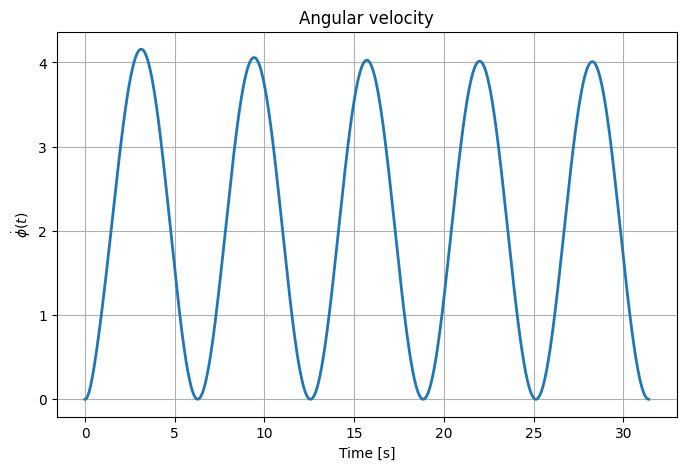

In [76]:
plt.figure(figsize=(8,5))
plt.plot(sol.t, sol.y[8,:], linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel(r'$\dot{\phi}(t)$')
plt.title('Angular velocity')
plt.grid(True)
plt.show()

The angular velocity oscillates periodically, but it never becomes negative. Because of that, the angle ϕ(t) keeps increasing over time instead of moving back and forth. This means the system keeps rotating, but its speed changes because of the sinusoidal input torque.